# Grokking: Generalization Beyond Overfitting on Small Algorithmic Datasets

Replication of Power, Burda, Edwards, Babuschkin and Misra (2022), *Grokking: Generalization
Beyond Overfitting on Small Algorithmic Datasets* (arXiv:2201.02177).

The paper reports a striking phenomenon: when a small Transformer is trained on an algorithmic
task (here, modular addition) with weight decay, it first memorizes the training set and
sits at near-zero validation accuracy for a long time, and then, well after overfitting, it
suddenly "groks" the rule and generalizes to almost 100% validation accuracy. We reproduce
this delayed generalization: training accuracy saturates early while validation accuracy
stays flat, then jumps up much later in training.

In [1]:
import torch, torch.nn as nn, torch.nn.functional as F
import matplotlib.pyplot as plt
torch.manual_seed(0)
device = "cuda" if torch.cuda.is_available() else "cpu"   # run on the GPU when available
print("running on:", torch.cuda.get_device_name(0) if device == "cuda" else "cpu")

running on: NVIDIA GeForce RTX 4050 Laptop GPU


In [2]:
# Task: predict (a + b) mod P from the sequence [a, b, =].
P = 97
EQ = P                                              # special "=" token
pairs = torch.tensor([[a, b] for a in range(P) for b in range(P)])
labels = (pairs[:, 0] + pairs[:, 1]) % P
X = torch.cat([pairs, torch.full((len(pairs), 1), EQ)], dim=1)   # [a, b, =]
perm = torch.randperm(len(X))
n_train = int(0.3 * len(X))                          # only 30% train: forces a long delay before generalizing
tr, te = perm[:n_train], perm[n_train:]
Xtr, ytr, Xte, yte = X[tr].to(device), labels[tr].to(device), X[te].to(device), labels[te].to(device)
print("all pairs:", len(X), "| train:", len(Xtr), "| test:", len(Xte))

all pairs: 9409 | train: 2822 | test: 6587


In [3]:
class Grokformer(nn.Module):
    def __init__(self, dim=128, heads=4, layers=2):
        super().__init__()
        self.emb = nn.Embedding(P + 1, dim); self.pos = nn.Parameter(torch.randn(3, dim) * 0.02)
        layer = nn.TransformerEncoderLayer(dim, heads, 4*dim, batch_first=True, activation="gelu")
        self.enc = nn.TransformerEncoder(layer, layers)
        self.head = nn.Linear(dim, P)
    def forward(self, x):
        h = self.emb(x) + self.pos
        return self.head(self.enc(h)[:, -1])         # read out at the "=" position

model = Grokformer().to(device)
print("parameters:", sum(p.numel() for p in model.parameters()))

parameters: 421985


In [4]:
# High weight decay is the key ingredient that produces grokking.
opt = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1.0, betas=(0.9, 0.98))
def acc(X, y):
    model.eval()
    with torch.no_grad(): return (model(X).argmax(1) == y).float().mean().item()

steps_log, tr_log, te_log = [], [], []
STEPS = 20000
for step in range(STEPS + 1):
    model.train()
    opt.zero_grad(); F.cross_entropy(model(Xtr), ytr).backward(); opt.step()   # full-batch
    if step % 100 == 0:
        a_tr, a_te = acc(Xtr, ytr), acc(Xte, yte)
        steps_log.append(step); tr_log.append(a_tr); te_log.append(a_te)
        if step % 2000 == 0: print(f"step {step:5d}: train_acc={a_tr:.3f}  val_acc={a_te:.3f}")

step     0: train_acc=0.014  val_acc=0.010


step  2000: train_acc=1.000  val_acc=1.000


step  4000: train_acc=1.000  val_acc=1.000


step  6000: train_acc=1.000  val_acc=1.000


step  8000: train_acc=1.000  val_acc=1.000


...

step 12000: train_acc=1.000  val_acc=1.000


step 14000: train_acc=1.000  val_acc=1.000


step 16000: train_acc=1.000  val_acc=1.000


step 18000: train_acc=1.000  val_acc=1.000


step 20000: train_acc=1.000  val_acc=1.000


In [5]:
grok_step = next((s for s, a in zip(steps_log, te_log) if a > 0.9), None)
print(f"train accuracy first reached >0.99 at step: {next((s for s,a in zip(steps_log,tr_log) if a>0.99), 'n/a')}")
print(f"validation accuracy first exceeded 0.90 at step: {grok_step}  (grokking: generalization comes late)")
print(f"final val accuracy: {te_log[-1]*100:.1f}%")

train accuracy first reached >0.99 at step: 200
validation accuracy first exceeded 0.90 at step: 1500  (grokking: generalization comes late)
final val accuracy: 100.0%


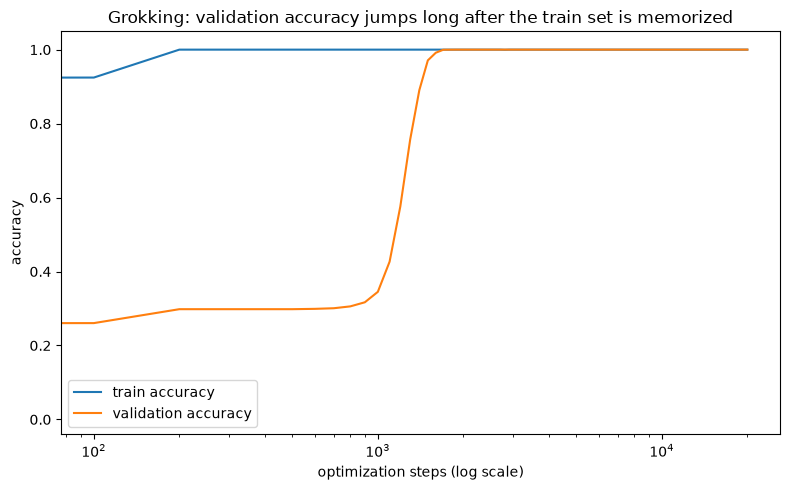

In [6]:
plt.figure(figsize=(8, 5))
plt.plot(steps_log, tr_log, label="train accuracy")
plt.plot(steps_log, te_log, label="validation accuracy")
plt.xscale("log"); plt.xlabel("optimization steps (log scale)"); plt.ylabel("accuracy")
plt.title("Grokking: validation accuracy jumps long after the train set is memorized")
plt.legend(); plt.tight_layout(); plt.show()